# **INSTITUTO POLITÉCNICO NACIONAL**

## **Algoritmos Bioinspirados**

**Nombre de los alumnos:**

* Arcia Portillo Héctor
* Cortés Reyes Karla Fátima
* Castro Luna Diego Francisco

## Dra. Miriam Pescador Rojas

## Notebook 4: Algoritmo 3 - Criterio de autoadaptación diseñado para FA

## ¿El FA tiene un criterio propio de autoadaptación?

No en su versión clásica. El algoritmo que tomamos como base (de Xin-She Yang) utiliza una reducción determinista y ciega, solo reduce el valor de α iteración tras iteración usando una fórmula matemática (α_nueva = α × δ), sin importar si el algoritmo está encontrando buenas soluciones o si está atascado.

## ¿Por qué se usó la logica de "1/5" en el código anterior?

Ya que el FA clásico no tiene un mecanismo que cuente éxitos, tuvimos que usar la lógica matemática de la Regla de 1/5 (que evalúa éxitos) y aplocarla al FA, así incorporamos un mecanismo de adaptación de parámetros en línea que varía de acuerdo con el número de éxitos.


# Criterio de auto-adaptación diseñado para FA

Este es un mecanismo de adaptación basado en éxitos específicos para luciérnagas.

En el FA existen dos parámetros que controlan la explotación y exploración.

1. α (Aleatoriedad): Controla qué tan grandes son los saltos ciegos.
2. γ (Absorción de luz): Controla qué tan lejos puede ver una luciérnaga.
* Si γ es bajo, ve lejos -> Exploración.
* Si γ es alto, solo ve a sus vecinas muy cercanas -> Explotación profunda.

Nuestro **nuevo criterio de éxito propio** será:

* Medimos la Tasa de Éxito (*SR*) = (Luciérnagas que mejoraron su fitness) / (Población total).

* Si *SR* es **alta** (ej. > 30%): El enjambre está en una buena zona. Mantenemos la aleatoriedad α alta para avanzar rápido, y reducimos γ
para que todas sigan a la mejor luciérnaga desde lejos.

* Si *SR* es **baja** (ej. < 10%): El enjambre está atascado (óptimo local). Reducimos α de manera drástica para hacer sintonía fina (pasos minúsculos) y aumentamos γ para que se ignoren las luces lejanas que resultan engañosas y exploten su vecindad inmediata.


In [ ]:
# Importamos NumPy para operaciones matemáticas vectorizadas y eficientes
import numpy as np
# Importamos Matplotlib para generar visualizaciones y gráficas de convergencia
import matplotlib.pyplot as plt

# ==========================================================
# 1. FUNCIONES BENCHMARK
# ==========================================================

# Función matemática de Ackley
def ackley(x):
    d = len(x) # Dimensión del problema
    sum_sq = np.sum(x**2) # Sumatoria de cuadrados
    sum_cos = np.sum(np.cos(2 * np.pi * x)) # Sumatoria de cosenos
    # Ecuación completa de Ackley
    return -20 * np.exp(-0.2 * np.sqrt(sum_sq / d)) - np.exp(sum_cos / d) + 20 + np.exp(1)

# Función matemática de Griewank
def griewank(x):
    d = len(x) # Dimensión del problema
    sum_term = np.sum(x**2) / 4000 # Sumatoria penalizada
    indices = np.arange(1, d + 1) # Arreglo de índices [1, 2, ..., d]
    prod_term = np.prod(np.cos(x / np.sqrt(indices))) # Productoria de cosenos escalados
    # Ecuación completa de Griewank
    return sum_term - prod_term + 1

# Función matemática de Rastrigin
def rastrigin(x):
    d = len(x) # Dimensión
    # Ecuación de Rastrigin (altamente multimodal)
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

# Función matemática de Rosenbrock
def rosenbrock(x):
    # Ecuación del valle de Rosenbrock iterando sobre pares de dimensiones
    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2.0 + (x[:-1] - 1)**2.0)

# ==========================================================
# 2. ALGORITMO DE LUCIÉRNAGAS ADAPTATIVO (Regla 1/5)
# ==========================================================

# Función para acotar el espacio de búsqueda
def apply_limits(ns, lb, ub):
    ns = np.maximum(ns, lb) # Trunca por debajo del límite inferior
    ns = np.minimum(ns, ub) # Trunca por encima del límite superior
    return ns

# Función principal del FA con adaptación en línea
def adaptive_firefly(func, d, bounds, N=100, G_MAX=5000):
    lb, ub = bounds[0], bounds[1]
    scale = np.abs(ub - lb)

    # Parámetros Base que ahora serán DINÁMICOS
    alpha = 0.5       # Salto aleatorio (Comienza alto para explorar)
    gamma = 1.0       # Absorción de luz (Comienza neutral)
    betamin = 0.2     # Atractividad mínima (Ese se queda estático)

    ns = lb + (ub - lb) * np.random.rand(N, d)
    lightn = np.ones(N) * np.inf

    history = []

    for g in range(G_MAX):

        # 1. Evaluamos la población actual
        current_fitness = np.array([func(ind) for ind in ns])

        # 2. CRITERIO PROPIO DE AUTO-ADAPTACIÓN POR CASOS DE ÉXITO (Para FA)
        if g > 0:
            # Contamos los casos de éxito (luciérnagas que mejoraron su fitness)
            exitos = np.sum(current_fitness < lightn)
            tasa_exito = exitos / N

            # Criterio adaptativo según el número de éxitos:
            if tasa_exito > 0.3:
                # ALTO ÉXITO: El enjambre fluye bien.
                # Aumentamos alpha para movernos rápido y reducimos gamma para ver lejos.
                alpha = min(alpha * 1.02, 1.0)
                gamma = max(gamma * 0.95, 0.1) # Límite inferior para no cegarlas

            elif tasa_exito < 0.1:
                # BAJO ÉXITO: El enjambre está estancado o cerca del óptimo global.
                # Reducimos alpha (pasos pequeños) y aumentamos gamma (explotación local extrema).
                alpha = max(alpha * 0.90, 1e-4) # Caída agresiva del salto aleatorio
                gamma = min(gamma * 1.05, 10.0) # Límite superior de absorción

            else:
                # ÉXITO MEDIO: Decaimiento natural suave (FA clásico)
                alpha = alpha * 0.99

        lightn = current_fitness.copy()

        # 3. Ordenamiento por brillo
        idx = np.argsort(lightn)
        lightn = lightn[idx]
        ns = ns[idx]

        history.append(lightn[0])

        nso = ns.copy()
        lighto = lightn.copy()

        # 4. Fase de movimiento
        for i in range(N):
            for j in range(N):
                if lighto[j] < lightn[i]:
                    r = np.linalg.norm(ns[i] - nso[j])
                    r_scaled = r / scale
                    # Aquí gamma ya está auto-adaptado por los éxitos
                    beta = (1.0 - betamin) * np.exp(-gamma * r_scaled**2) + betamin
                    # Aquí alpha ya está auto-adaptado por los éxitos
                    tmpf = alpha * (np.random.rand(d) - 0.5) * scale
                    ns[i] = ns[i] * (1 - beta) + nso[j] * beta + tmpf

        ns = apply_limits(ns, lb, ub)

    return ns[0], lightn[0], history

# ==========================================================
# 3. EJECUCIÓN DEL EXPERIMENTO (30 EJECUCIONES)
# ==========================================================
if __name__ == "__main__":
    problemas = {
        "Ackley": (ackley, [-32.768, 32.768]),
        "Griewank": (griewank, [-600, 600]),
        "Rastrigin": (rastrigin, [-5.12, 5.12]),
        "Rosenbrock": (rosenbrock, [-2.048, 2.048])
    }

    D = 10 # 10 variables de decisión
    N_RUNS = 30 # 30 ejecuciones independientes
    np.random.seed(42) # Semilla matemática

    for nombre_prob, (funcion, limites) in problemas.items():
        print(f"\n{'='*50}\n RESOLVIENDO: {nombre_prob.upper()}\n{'='*50}")
        resultados_finales = []
        curvas_convergencia = []

        for corrida in range(N_RUNS):
            print(f"-> Corrida {corrida + 1} de {N_RUNS}...")
            # Llamamos al algoritmo modificado
            mejor_pos, mejor_fit, historial = adaptive_firefly(funcion, D, limites, N=100, G_MAX=5000)
            resultados_finales.append(mejor_fit)
            curvas_convergencia.append(historial)

        resultados_finales = np.array(resultados_finales)
        print(f"\n--- ESTADÍSTICAS ({nombre_prob}) ---")
        print(f"PROMEDIO (Media): {np.mean(resultados_finales):.6e}")
        print(f"DESV. ESTÁNDAR:   {np.std(resultados_finales):.6e}")

        print("\nDatos para prueba de Wilcoxon (30 ejecuciones):")
        print(list(resultados_finales)) # Imprime lista directa para copiar-pegar

        # Graficamos la convergencia
        mediana_curva = np.median(np.array(curvas_convergencia), axis=0)
        plt.figure(figsize=(10, 6))
        plt.plot(mediana_curva, label="FA Adaptativo (Mediana)", color='darkviolet')
        plt.yscale('log')
        plt.title(f"Convergencia {nombre_prob} (30 corridas)")
        plt.xlabel("Generaciones")
        plt.ylabel("Mejor Fitness (Log)")
        plt.grid(True, ls="--", alpha=0.5)
        plt.legend()
        plt.savefig(f"convergencia_{nombre_prob}.png")
        plt.show()

# Ejecución independiente para cada función

# Función Ackley

In [ ]:
# Importamos NumPy para operaciones matemáticas vectorizadas y eficientes
import numpy as np
# Importamos Matplotlib para generar visualizaciones y gráficas de convergencia
import matplotlib.pyplot as plt

# ==========================================================
# 1. FUNCIÓN BENCHMARK: ACKLEY
# ==========================================================
# Definimos la función matemática de Ackley
def ackley(x):
    # Obtenemos la dimensión del problema (cantidad de variables)
    d = len(x)
    # Calculamos la sumatoria de los cuadrados de cada variable
    sum_sq = np.sum(x**2)
    # Calculamos la sumatoria de los cosenos de cada variable escalada
    sum_cos = np.sum(np.cos(2 * np.pi * x))
    # Retornamos el valor evaluado en la ecuación completa de Ackley
    return -20 * np.exp(-0.2 * np.sqrt(sum_sq / d)) - np.exp(sum_cos / d) + 20 + np.exp(1)

# ==========================================================
# 2. ALGORITMO DE LUCIÉRNAGAS ADAPTATIVO
# ==========================================================
# Función para asegurar que las luciérnagas no salgan del espacio de búsqueda
def apply_limits(ns, lb, ub):
    # Trunca los valores por debajo del límite inferior (lb)
    ns = np.maximum(ns, lb)
    # Trunca los valores por encima del límite superior (ub)
    ns = np.minimum(ns, ub)
    # Devuelve las posiciones corregidas
    return ns

# Función principal del Algoritmo de Luciérnagas (FA) con adaptación
def adaptive_firefly(func, d, bounds, N=100, G_MAX=5000):
    # Extraemos el límite inferior y superior del problema
    lb, ub = bounds[0], bounds[1]
    # Calculamos la escala total del espacio de búsqueda
    scale = np.abs(ub - lb)

    # Inicializamos alpha: Salto aleatorio (Comienza en 0.5 para explorar)
    alpha = 0.5
    # Inicializamos gamma: Absorción de luz (Comienza en 1.0)
    gamma = 1.0
    # Inicializamos betamin: Atractividad mínima base constante
    betamin = 0.2

    # Generamos la población inicial aleatoria dentro de los límites
    ns = lb + (ub - lb) * np.random.rand(N, d)
    # Inicializamos el vector de luz (fitness) con infinito (peor valor posible)
    lightn = np.ones(N) * np.inf
    # Creamos una lista vacía para guardar el mejor fitness de cada generación
    history = []

    # Bucle principal que iterará hasta la generación máxima (G_MAX)
    for g in range(G_MAX):
        # Evaluamos el fitness actual de todas las luciérnagas
        current_fitness = np.array([func(ind) for ind in ns])

        # A partir de la segunda generación, aplicamos la regla adaptativa
        if g > 0:
            # Contamos cuántas luciérnagas mejoraron su fitness respecto a la iteración pasada
            exitos = np.sum(current_fitness < lightn)
            # Calculamos la tasa de éxito dividiendo los éxitos entre el total de la población
            tasa_exito = exitos / N

            # Si hay alto éxito (>30%), el enjambre se mueve bien
            if tasa_exito > 0.3:
                # Aumentamos alpha para movernos más rápido (tope en 1.0)
                alpha = min(alpha * 1.02, 1.0)
                # Reducimos gamma para que se vean desde más lejos (tope mínimo 0.1)
                gamma = max(gamma * 0.95, 0.1)
            # Si hay bajo éxito (<10%), el enjambre está estancado
            elif tasa_exito < 0.1:
                # Reducimos alpha drásticamente para pasos finos (tope mínimo 1e-4)
                alpha = max(alpha * 0.90, 1e-4)
                # Aumentamos gamma para explotación muy local (tope máximo 10.0)
                gamma = min(gamma * 1.05, 10.0)
            # Si el éxito es medio, aplicamos decaimiento suave clásico
            else:
                # Disminuimos ligeramente alpha
                alpha = alpha * 0.99

        # Actualizamos la luz de las luciérnagas con el fitness actual
        lightn = current_fitness.copy()
        # Obtenemos los índices ordenados de mejor a peor fitness
        idx = np.argsort(lightn)
        # Ordenamos el vector de luz de mejor a peor
        lightn = lightn[idx]
        # Ordenamos las posiciones de las luciérnagas de mejor a peor
        ns = ns[idx]

        # Guardamos en el historial el fitness de la mejor luciérnaga (la primera)
        history.append(lightn[0])

        # Hacemos una copia de las posiciones actuales para la fase de movimiento
        nso = ns.copy()
        # Hacemos una copia de la luz actual
        lighto = lightn.copy()

        # Bucle para cada luciérnaga i
        for i in range(N):
            # Comparamos la luciérnaga i con todas las demás luciérnagas j
            for j in range(N):
                # Si la luciérnaga j es más brillante (menor fitness) que i
                if lighto[j] < lightn[i]:
                    # Calculamos la distancia euclidiana entre ambas
                    r = np.linalg.norm(ns[i] - nso[j])
                    # Escalamos la distancia relativa al tamaño del espacio
                    r_scaled = r / scale
                    # Calculamos la atractividad beta usando la función exponencial y gamma
                    beta = (1.0 - betamin) * np.exp(-gamma * r_scaled**2) + betamin
                    # Calculamos el factor de movimiento aleatorio con alpha
                    tmpf = alpha * (np.random.rand(d) - 0.5) * scale
                    # Movemos la luciérnaga i hacia la luciérnaga j
                    ns[i] = ns[i] * (1 - beta) + nso[j] * beta + tmpf

        # Aplicamos los límites para que nadie salga del espacio de búsqueda
        ns = apply_limits(ns, lb, ub)

    # Retornamos la mejor posición, el mejor fitness y el historial completo
    return ns[0], lightn[0], history

# ==========================================================
# 3. EJECUCIÓN DEL EXPERIMENTO (30 CORRIDAS)
# ==========================================================
# Bloque principal de ejecución
if __name__ == "__main__":
    # Definimos el nombre del problema actual
    nombre_prob = "Ackley"
    # Asignamos la función matemática a evaluar
    funcion = ackley
    # Definimos los límites específicos para Ackley
    limites = [-32.768, 32.768]
    # Definimos 10 dimensiones para el problema
    D = 10
    # Configuramos 30 corridas independientes
    N_RUNS = 30
    # Fijamos una semilla aleatoria para que el código sea reproducible
    np.random.seed(42)

    # Imprimimos un encabezado en consola
    print(f"\n{'='*50}\n RESOLVIENDO: {nombre_prob.upper()}\n{'='*50}")
    # Lista para almacenar el mejor fitness final de cada corrida
    resultados_finales = []
    # Lista para almacenar la curva completa de convergencia de cada corrida
    curvas_convergencia = []

    # Bucle que ejecutará el algoritmo 30 veces
    for corrida in range(N_RUNS):
        # Imprimimos en qué corrida vamos
        print(f"-> Ejecución {corrida + 1} de {N_RUNS}...")
        # Llamamos a la función del algoritmo y guardamos los resultados
        mejor_pos, mejor_fit, historial = adaptive_firefly(funcion, D, limites, N=100, G_MAX=5000)
        # Añadimos el mejor fitness final a la lista
        resultados_finales.append(mejor_fit)
        # Añadimos el historial a la matriz de curvas
        curvas_convergencia.append(historial)

    # Convertimos la lista de resultados a un arreglo de NumPy
    resultados_finales = np.array(resultados_finales)
    # Imprimimos sección de estadísticas
    print(f"\n--- ESTADÍSTICAS ({nombre_prob}) ---")
    # Imprimimos la Media de las 30 corridas en formato científico
    print(f"Promedio (Media): {np.mean(resultados_finales):.6e}")
    # Imprimimos la Desviación Estándar de las 30 corridas
    print(f"Desviación estándar:   {np.std(resultados_finales):.6e}")
    # Imprimimos un mensaje para los datos crudos
    print("\nDatos para comparación:")
    # Imprimimos la lista cruda para facilitar el copiado
    print(list(resultados_finales))

    # Calculamos la mediana de todas las curvas de convergencia generación por generación
    mediana_curva = np.median(np.array(curvas_convergencia), axis=0)
    # Creamos una figura de Matplotlib de 10x6 pulgadas
    plt.figure(figsize=(10, 6))
    # Graficamos la curva mediana en color violeta oscuro
    plt.plot(mediana_curva, label="FA Adaptativo (Mediana)", color='darkviolet')
    # Ponemos el eje Y en escala logarítmica para ver mejor la convergencia
    plt.yscale('log')
    # Añadimos un título al gráfico
    plt.title(f"Convergencia {nombre_prob} (30 ejecuciones)")
    # Etiquetamos el eje X
    plt.xlabel("Generaciones")
    # Etiquetamos el eje Y
    plt.ylabel("Mejor Fitness (Log)")
    # Añadimos una cuadrícula punteada al fondo
    plt.grid(True, ls="--", alpha=0.5)
    # Mostramos la leyenda del gráfico
    plt.legend()
    # Guardamos el gráfico como una imagen PNG
    plt.savefig(f"convergencia_{nombre_prob}.png")
    # Mostramos el gráfico en pantalla (en la libreta de Colab)
    plt.show()


 RESOLVIENDO: ACKLEY
-> Ejecución 1 de 30...
-> Ejecución 2 de 30...
-> Ejecución 3 de 30...
-> Ejecución 4 de 30...
-> Ejecución 5 de 30...
-> Ejecución 6 de 30...
-> Ejecución 7 de 30...
-> Ejecución 8 de 30...


# Función Griewank


 RESOLVIENDO: GRIEWANK
-> Ejecución 1 de 30...
-> Ejecución 2 de 30...
-> Ejecución 3 de 30...
-> Ejecución 4 de 30...
-> Ejecución 5 de 30...
-> Ejecución 6 de 30...
-> Ejecución 7 de 30...
-> Ejecución 8 de 30...
-> Ejecución 9 de 30...
-> Ejecución 10 de 30...
-> Ejecución 11 de 30...
-> Ejecución 12 de 30...
-> Ejecución 13 de 30...
-> Ejecución 14 de 30...
-> Ejecución 15 de 30...
-> Ejecución 16 de 30...
-> Ejecución 17 de 30...
-> Ejecución 18 de 30...
-> Ejecución 19 de 30...
-> Ejecución 20 de 30...
-> Ejecución 21 de 30...
-> Ejecución 22 de 30...
-> Ejecución 23 de 30...
-> Ejecución 24 de 30...
-> Ejecución 25 de 30...
-> Ejecución 26 de 30...
-> Ejecución 27 de 30...
-> Ejecución 28 de 30...
-> Ejecución 29 de 30...
-> Ejecución 30 de 30...

--- ESTADÍSTICAS (Griewank) ---
Promedio (Media): 2.210864e+01
Desviación estándar:   4.627342e+00

Datos para comparación:
[np.float64(21.62397292370445), np.float64(27.889473320364253), np.float64(17.031200377244545), np.float64(16.

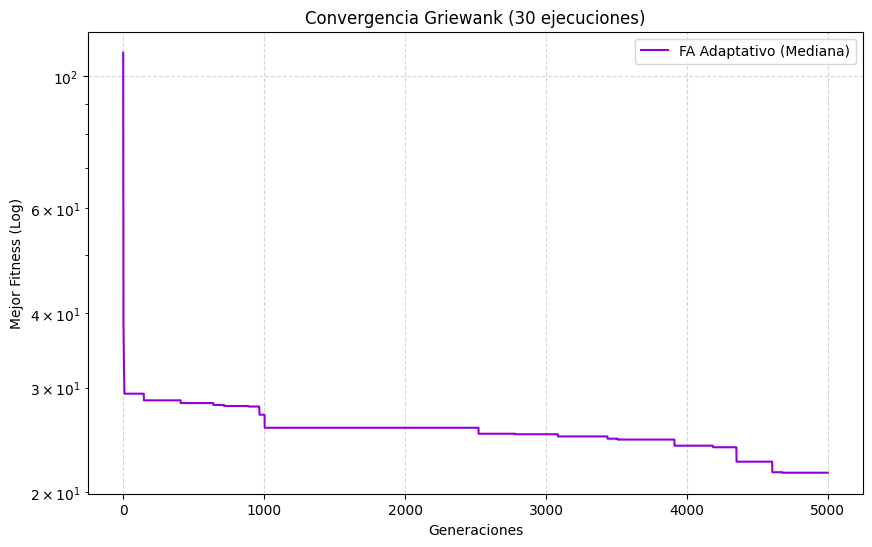

In [ ]:
# Importamos NumPy para operaciones matemáticas eficientes
import numpy as np
# Importamos Matplotlib para la generación de gráficas
import matplotlib.pyplot as plt

# ==========================================================
# 1. FUNCIÓN BENCHMARK: GRIEWANK
# ==========================================================
# Definimos la función matemática de Griewank
def griewank(x):
    # Obtenemos el número de variables (dimensión)
    d = len(x)
    # Calculamos la sumatoria dividida entre 4000
    sum_term = np.sum(x**2) / 4000
    # Creamos un arreglo de índices del 1 al d para la productoria
    indices = np.arange(1, d + 1)
    # Calculamos la productoria de cosenos escalados por la raíz del índice
    prod_term = np.prod(np.cos(x / np.sqrt(indices)))
    # Retornamos la ecuación final de Griewank
    return sum_term - prod_term + 1

# ==========================================================
# 2. ALGORITMO DE LUCIÉRNAGAS ADAPTATIVO
# ==========================================================
# Función para acotar a las luciérnagas dentro del espacio permitido
def apply_limits(ns, lb, ub):
    # Límite inferior: si es menor que lb, lo vuelve lb
    ns = np.maximum(ns, lb)
    # Límite superior: si es mayor que ub, lo vuelve ub
    ns = np.minimum(ns, ub)
    # Retorna las posiciones corregidas
    return ns

# Definición del FA Adaptativo
def adaptive_firefly(func, d, bounds, N=100, G_MAX=5000):
    # Separa límites inferiores y superiores
    lb, ub = bounds[0], bounds[1]
    # Calcula el ancho total del espacio de búsqueda
    scale = np.abs(ub - lb)

    # Parámetro base alpha (salto inicial)
    alpha = 0.5
    # Parámetro base gamma (absorción inicial)
    gamma = 1.0
    # Atractividad mínima garantizada
    betamin = 0.2

    # Inicialización aleatoria de la población
    ns = lb + (ub - lb) * np.random.rand(N, d)
    # Array de fitness inicializado en infinito
    lightn = np.ones(N) * np.inf
    # Lista para almacenar el progreso del mejor fitness
    history = []

    # Bucle generacional principal
    for g in range(G_MAX):
        # Evalúa el fitness de la población en la generación actual
        current_fitness = np.array([func(ind) for ind in ns])

        # A partir de la iteración 1 se aplica la adaptación
        if g > 0:
            # Cuenta casos donde el fitness actual mejoró respecto al anterior
            exitos = np.sum(current_fitness < lightn)
            # Calcula el porcentaje de éxito
            tasa_exito = exitos / N

            # Condición de éxito alto
            if tasa_exito > 0.3:
                # Expande el paso aleatorio (explora)
                alpha = min(alpha * 1.02, 1.0)
                # Baja la absorción para ver más lejos
                gamma = max(gamma * 0.95, 0.1)
            # Condición de éxito bajo
            elif tasa_exito < 0.1:
                # Contrae el paso para converger (explota)
                alpha = max(alpha * 0.90, 1e-4)
                # Aumenta la absorción para focalizarse cerca
                gamma = min(gamma * 1.05, 10.0)
            # Condición intermedia
            else:
                # Decaimiento suave de iteración
                alpha = alpha * 0.99

        # Guarda el nuevo estado de luz
        lightn = current_fitness.copy()
        # Obtiene índices para ordenar de mejor a peor (minimizando)
        idx = np.argsort(lightn)
        # Ordena luces
        lightn = lightn[idx]
        # Ordena posiciones acordes a la luz
        ns = ns[idx]

        # Guarda la luz del mejor individuo actual en el historial
        history.append(lightn[0])

        # Clona las posiciones para poder mover sin pisar datos
        nso = ns.copy()
        # Clona las luces
        lighto = lightn.copy()

        # Iteración sobre cada luciérnaga (para moverla)
        for i in range(N):
            # Iteración sobre el resto del enjambre (para compararla)
            for j in range(N):
                # Si 'j' brilla más que 'i'
                if lighto[j] < lightn[i]:
                    # Distancia entre ellas
                    r = np.linalg.norm(ns[i] - nso[j])
                    # Distancia ajustada al espacio
                    r_scaled = r / scale
                    # Fórmula de atracción
                    beta = (1.0 - betamin) * np.exp(-gamma * r_scaled**2) + betamin
                    # Fórmula de salto aleatorio guiado
                    tmpf = alpha * (np.random.rand(d) - 0.5) * scale
                    # Ecuación de movimiento de la luciérnaga 'i'
                    ns[i] = ns[i] * (1 - beta) + nso[j] * beta + tmpf

        # Evita que se salgan del espacio de búsqueda
        ns = apply_limits(ns, lb, ub)

    # Retorna solución, fitness y curva de la ejecución
    return ns[0], lightn[0], history

# ==========================================================
# 3. EJECUCIÓN (30 CORRIDAS)
# ==========================================================
# Punto de entrada principal
if __name__ == "__main__":
    # Nombre a mostrar
    nombre_prob = "Griewank"
    # Referencia a la función Griewank
    funcion = griewank
    # Límites para este problema matemático
    limites = [-600, 600]
    # 10 Variables a optimizar
    D = 10
    # 30 Repeticiones
    N_RUNS = 30
    # Semilla para reproducibilidad de errores
    np.random.seed(42)

    # Título en consola
    print(f"\n{'='*50}\n RESOLVIENDO: {nombre_prob.upper()}\n{'='*50}")
    # Arreglo vacío de resultados numéricos
    resultados_finales = []
    # Arreglo vacío de vectores de curvas
    curvas_convergencia = []

    # Ciclo de 30 iteraciones
    for corrida in range(N_RUNS):
        # Mensaje de trazabilidad
        print(f"-> Ejecución {corrida + 1} de {N_RUNS}...")
        # Ejecución del algoritmo y captura de respuestas
        mejor_pos, mejor_fit, historial = adaptive_firefly(funcion, D, limites, N=100, G_MAX=5000)
        # Se anota el resultado final de esta corrida
        resultados_finales.append(mejor_fit)
        # Se anota la curva completa
        curvas_convergencia.append(historial)

    # Transforma lista a vector de NumPy
    resultados_finales = np.array(resultados_finales)
    # Muestra el título de resultados
    print(f"\n--- ESTADÍSTICAS ({nombre_prob}) ---")
    # Imprime el promedio estadístico
    print(f"Promedio (Media): {np.mean(resultados_finales):.6e}")
    # Imprime la desviación estándar
    print(f"Desviación estándar:   {np.std(resultados_finales):.6e}")
    # Mensaje para pruebas estadísticas futuras
    print("\nDatos para comparación:")
    # Despliega la lista cruda de 30 datos
    print(list(resultados_finales))

    # Saca la mediana por columna (generación) de las 30 corridas
    mediana_curva = np.median(np.array(curvas_convergencia), axis=0)
    # Define la caja de la gráfica
    plt.figure(figsize=(10, 6))
    # Dibuja la curva
    plt.plot(mediana_curva, label="FA Adaptativo (Mediana)", color='darkviolet')
    # Escala logarítmica para ver los decibeles de caída
    plt.yscale('log')
    # Título de gráfica
    plt.title(f"Convergencia {nombre_prob} (30 ejecuciones)")
    # Eje de abscisas
    plt.xlabel("Generaciones")
    # Eje de ordenadas
    plt.ylabel("Mejor Fitness (Log)")
    # Cuadrícula
    plt.grid(True, ls="--", alpha=0.5)
    # Leyenda
    plt.legend()
    # Guardar como archivo de imagen
    plt.savefig(f"convergencia_{nombre_prob}.png")
    # Renderizar pantalla final
    plt.show()

# Función Rastrigin


 RESOLVIENDO: RASTRIGIN
-> Ejecución 1 de 30...
-> Ejecución 2 de 30...
-> Ejecución 3 de 30...
-> Ejecución 4 de 30...
-> Ejecución 5 de 30...
-> Ejecución 6 de 30...
-> Ejecución 7 de 30...
-> Ejecución 8 de 30...
-> Ejecución 9 de 30...
-> Ejecución 10 de 30...
-> Ejecución 11 de 30...
-> Ejecución 12 de 30...
-> Ejecución 13 de 30...
-> Ejecución 14 de 30...
-> Ejecución 15 de 30...
-> Ejecución 16 de 30...
-> Ejecución 17 de 30...
-> Ejecución 18 de 30...
-> Ejecución 19 de 30...
-> Ejecución 20 de 30...
-> Ejecución 21 de 30...
-> Ejecución 22 de 30...
-> Ejecución 23 de 30...
-> Ejecución 24 de 30...
-> Ejecución 25 de 30...
-> Ejecución 26 de 30...
-> Ejecución 27 de 30...
-> Ejecución 28 de 30...
-> Ejecución 29 de 30...
-> Ejecución 30 de 30...

--- ESTADÍSTICAS (Rastrigin) ---
Promedio (Media): 5.493840e+01
Desviación estándar:   5.141708e+00

Datos para comparación:
[np.float64(59.2627137944635), np.float64(55.81301530499384), np.float64(55.34866845507914), np.float64(43.6

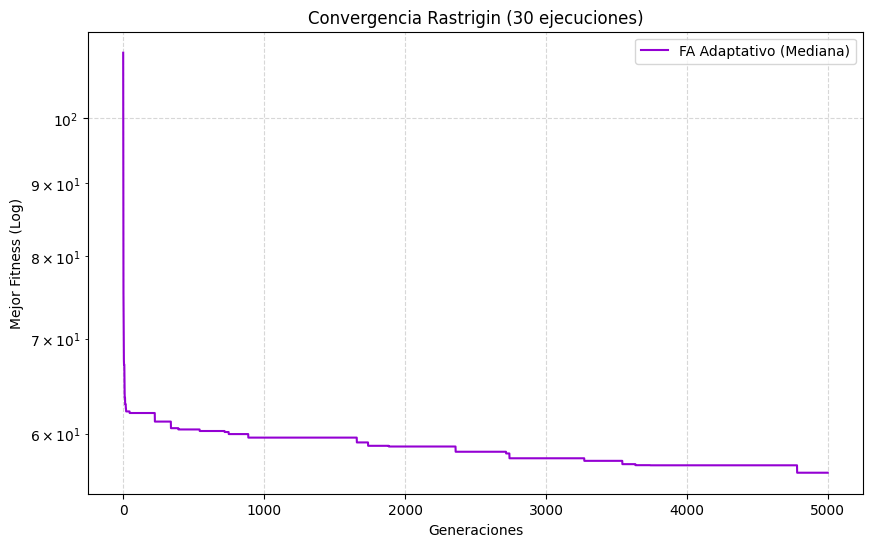

In [ ]:
# Módulo para vectores y matrices matemáticas
import numpy as np
# Módulo para dibujos e imágenes de gráficas
import matplotlib.pyplot as plt

# ==========================================================
# 1. FUNCIÓN BENCHMARK: RASTRIGIN
# ==========================================================
# Se define la función Rastrigin (altamente multimodal)
def rastrigin(x):
    # Se cuenta la cantidad de variables
    d = len(x)
    # Se aplica la ecuación matemática pura de Rastrigin
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

# ==========================================================
# 2. ALGORITMO DE LUCIÉRNAGAS ADAPTATIVO
# ==========================================================
# Acota el vector de posiciones a los bordes permitidos
def apply_limits(ns, lb, ub):
    # Verifica borde mínimo
    ns = np.maximum(ns, lb)
    # Verifica borde máximo
    ns = np.minimum(ns, ub)
    # Retorna vector sano
    return ns

# Define el FA con auto-adaptación de paso (1/5 rule)
def adaptive_firefly(func, d, bounds, N=100, G_MAX=5000):
    # Fronteras inferiores y superiores
    lb, ub = bounds[0], bounds[1]
    # Amplitud total del dominio
    scale = np.abs(ub - lb)

    # Declaración de alpha dinámico inicial
    alpha = 0.5
    # Declaración de gamma dinámico inicial
    gamma = 1.0
    # Declaración de beta_min estático
    betamin = 0.2

    # Distribución inicial aleatoria uniforme
    ns = lb + (ub - lb) * np.random.rand(N, d)
    # Vector de evaluación inicializado con peor caso (infinito)
    lightn = np.ones(N) * np.inf
    # Lista de convergencia
    history = []

    # Loop de 0 a 4999 (5000 generaciones)
    for g in range(G_MAX):
        # Mapea la función Rastrigin sobre la población
        current_fitness = np.array([func(ind) for ind in ns])

        # Si no es la generación cero (para poder comparar)
        if g > 0:
            # Cuenta cuantas bajaron su puntaje (mejoraron)
            exitos = np.sum(current_fitness < lightn)
            # Razón de éxito
            tasa_exito = exitos / N

            # Criterio adaptativo: mucha exploración útil
            if tasa_exito > 0.3:
                # Sube la agresividad del salto
                alpha = min(alpha * 1.02, 1.0)
                # Baja la absorción para verse a distancia
                gamma = max(gamma * 0.95, 0.1)
            # Criterio adaptativo: estancamiento
            elif tasa_exito < 0.1:
                # Baja la agresividad para converger microscópicamente
                alpha = max(alpha * 0.90, 1e-4)
                # Sube absorción para ignorar luces lejanas
                gamma = min(gamma * 1.05, 10.0)
            # Criterio neutro
            else:
                # Disminución paulatina estándar de FA
                alpha = alpha * 0.99

        # Fija las nuevas intensidades luminosas
        lightn = current_fitness.copy()
        # Obtiene mapa de ordenación ascendente
        idx = np.argsort(lightn)
        # Ordena brillo (0 es el mejor)
        lightn = lightn[idx]
        # Aplica orden a las posiciones
        ns = ns[idx]

        # Apunta el récord actual en el histórico
        history.append(lightn[0])

        # Respaldos temporales para el doble bucle
        nso = ns.copy()
        # Respaldo temporal de luces
        lighto = lightn.copy()

        # Bucle for para la luciérnaga origen
        for i in range(N):
            # Bucle for para la luciérnaga destino
            for j in range(N):
                # ¿El destino brilla más (tiene menor error)?
                if lighto[j] < lightn[i]:
                    # Calcula vector distancia
                    r = np.linalg.norm(ns[i] - nso[j])
                    # Normaliza distancia frente al espacio general
                    r_scaled = r / scale
                    # Ecuación de atractividad decreciente por distancia
                    beta = (1.0 - betamin) * np.exp(-gamma * r_scaled**2) + betamin
                    # Ecuación de ruido aleatorio direccional
                    tmpf = alpha * (np.random.rand(d) - 0.5) * scale
                    # Computa la nueva coordenada en base al movimiento
                    ns[i] = ns[i] * (1 - beta) + nso[j] * beta + tmpf

        # Corrige desbordes espaciales post-movimiento
        ns = apply_limits(ns, lb, ub)

    # Finaliza devolviendo el ganador y su historia
    return ns[0], lightn[0], history

# ==========================================================
# 3. EJECUCIÓN (30 CORRIDAS)
# ==========================================================
# Control principal de Python
if __name__ == "__main__":
    # Nombre del problema
    nombre_prob = "Rastrigin"
    # Puntero a función Rastrigin
    funcion = rastrigin
    # Límites oficiales del benchmark
    limites = [-5.12, 5.12]
    # D=10 Variables
    D = 10
    # 30 experimentos
    N_RUNS = 30
    # Semilla para anular variabilidad del azar en desarrollo
    np.random.seed(42)

    # Consola output
    print(f"\n{'='*50}\n RESOLVIENDO: {nombre_prob.upper()}\n{'='*50}")
    # Contenedor de mejores fitness finales
    resultados_finales = []
    # Contenedor de iteraciones vs fitness
    curvas_convergencia = []

    # Loop experimentador
    for corrida in range(N_RUNS):
        # Tracker visual de progreso
        print(f"-> Ejecución {corrida + 1} de {N_RUNS}...")
        # Llama a FA
        mejor_pos, mejor_fit, historial = adaptive_firefly(funcion, D, limites, N=100, G_MAX=5000)
        # Añade el valor escalar
        resultados_finales.append(mejor_fit)
        # Añade el vector 1D
        curvas_convergencia.append(historial)

    # Casting a matriz np
    resultados_finales = np.array(resultados_finales)
    # Impresora de resumen
    print(f"\n--- ESTADÍSTICAS ({nombre_prob}) ---")
    # Calcula media geométrica
    print(f"Promedio (Media): {np.mean(resultados_finales):.6e}")
    # Calcula dispersión
    print(f"Desviación estándar:   {np.std(resultados_finales):.6e}")
    # Info de validación estadística
    print("\nDatos para comparación:")
    # Impresión en formato raw list de python
    print(list(resultados_finales))

    # Extrae el comportamiento intermedio estadístico (Mediana transversal)
    mediana_curva = np.median(np.array(curvas_convergencia), axis=0)
    # Dimensiona la figura a exportar
    plt.figure(figsize=(10, 6))
    # Configura trazado de línea
    plt.plot(mediana_curva, label="FA Adaptativo (Mediana)", color='darkviolet')
    # Configura escala Y
    plt.yscale('log')
    # Título principal
    plt.title(f"Convergencia {nombre_prob} (30 ejecuciones)")
    # Nombre del eje X
    plt.xlabel("Generaciones")
    # Nombre del eje Y
    plt.ylabel("Mejor Fitness (Log)")
    # Formato de grilla
    plt.grid(True, ls="--", alpha=0.5)
    # Muestra caja de etiquetas
    plt.legend()
    # Guarda en disco (sesión de colab)
    plt.savefig(f"convergencia_{nombre_prob}.png")
    # Abre visualización
    plt.show()

# Función Rosenbrock


 RESOLVIENDO: ROSENBROCK
-> Ejecución 1 de 30...
-> Ejecución 2 de 30...
-> Ejecución 3 de 30...
-> Ejecución 4 de 30...
-> Ejecución 5 de 30...
-> Ejecución 6 de 30...
-> Ejecución 7 de 30...
-> Ejecución 8 de 30...
-> Ejecución 9 de 30...
-> Ejecución 10 de 30...
-> Ejecución 11 de 30...
-> Ejecución 12 de 30...
-> Ejecución 13 de 30...
-> Ejecución 14 de 30...
-> Ejecución 15 de 30...
-> Ejecución 16 de 30...
-> Ejecución 17 de 30...
-> Ejecución 18 de 30...
-> Ejecución 19 de 30...
-> Ejecución 20 de 30...
-> Ejecución 21 de 30...
-> Ejecución 22 de 30...
-> Ejecución 23 de 30...
-> Ejecución 24 de 30...
-> Ejecución 25 de 30...
-> Ejecución 26 de 30...
-> Ejecución 27 de 30...
-> Ejecución 28 de 30...
-> Ejecución 29 de 30...
-> Ejecución 30 de 30...

--- ESTADÍSTICAS (Rosenbrock) ---
Promedio (Media): 9.400369e+01
Desviación estándar:   1.977550e+01

Datos para comparación:
[np.float64(63.21293357534219), np.float64(112.96301305380469), np.float64(110.8844761338992), np.float64(

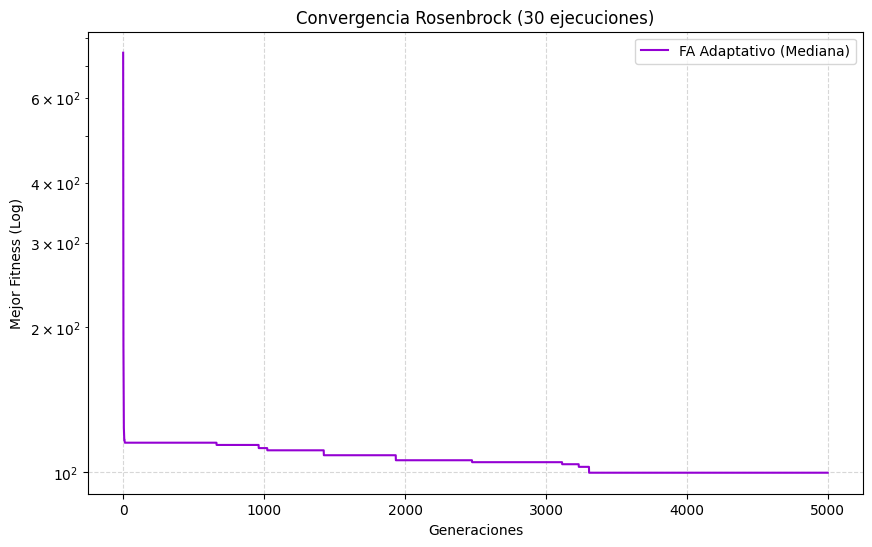

In [ ]:
# Librería base para matrices de datos numéricos
import numpy as np
# Librería base para trazado 2D
import matplotlib.pyplot as plt

# ==========================================================
# 1. FUNCIÓN BENCHMARK: ROSENBROCK
# ==========================================================
# Define función del valle de Rosenbrock
def rosenbrock(x):
    # Ecuación vectorizada para las 10 dimensiones sin usar bucles for
    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2.0 + (x[:-1] - 1)**2.0)

# ==========================================================
# 2. ALGORITMO DE LUCIÉRNAGAS ADAPTATIVO
# ==========================================================
# Función limitadora de espacio continuo
def apply_limits(ns, lb, ub):
    # Protege contra subdesbordamiento del límite inferior
    ns = np.maximum(ns, lb)
    # Protege contra sobredesbordamiento del límite superior
    ns = np.minimum(ns, ub)
    # Entrega matriz reparada
    return ns

# Envoltorio del algoritmo heurístico
def adaptive_firefly(func, d, bounds, N=100, G_MAX=5000):
    # Define suelo y techo
    lb, ub = bounds[0], bounds[1]
    # Define la distancia total del segmento de búsqueda
    scale = np.abs(ub - lb)

    # Alpha inicial (pasos largos)
    alpha = 0.5
    # Gamma inicial (visión normal)
    gamma = 1.0
    # Atractividad residual (para que nunca deje de moverse si se atraen)
    betamin = 0.2

    # Inyección de enjambre en mapa (Posiciones aleatorias X y Y...D)
    ns = lb + (ub - lb) * np.random.rand(N, d)
    # Inicializa luz de las luciérnagas de forma pésima para que cualquier cosa sea mejor
    lightn = np.ones(N) * np.inf
    # Histórico de iteraciones (Para graficar después)
    history = []

    # Iterador por generación (G_MAX = 5000)
    for g in range(G_MAX):
        # Vectoriza la evaluación matemática sobre los N individuos
        current_fitness = np.array([func(ind) for ind in ns])

        # Bloque de IA de Adaptación (sólo actúa si existe pasado con cual comparar)
        if g > 0:
            # Cuenta luces que brillaron más que ayer
            exitos = np.sum(current_fitness < lightn)
            # Normaliza conteo (0 a 1)
            tasa_exito = exitos / N

            # Éxito masivo
            if tasa_exito > 0.3:
                # Permite moverse más bruscamente
                alpha = min(alpha * 1.02, 1.0)
                # Baja opacidad del medio ambiente
                gamma = max(gamma * 0.95, 0.1)
            # Fracaso masivo (estancamiento)
            elif tasa_exito < 0.1:
                # Frena los saltos bruscos (micro-búsqueda)
                alpha = max(alpha * 0.90, 1e-4)
                # Cierra el campo de visión (ceguera lejana)
                gamma = min(gamma * 1.05, 10.0)
            # Evolución normal
            else:
                # Reduce el ruido natural gradualmente (annealing)
                alpha = alpha * 0.99

        # La nueva luz es la luz actual evaluada
        lightn = current_fitness.copy()
        # Encuentra los índices mágicos que ordenan el array de menor a mayor error
        idx = np.argsort(lightn)
        # Ordenación física de intensidades
        lightn = lightn[idx]
        # Ordenación física de coordenadas
        ns = ns[idx]

        # Memoria del mejor en esta generación (el índice 0 gracias al sort anterior)
        history.append(lightn[0])

        # Posiciones previas fotocopiadas
        nso = ns.copy()
        # Luces previas fotocopiadas
        lighto = lightn.copy()

        # Ciclo de atracción principal (Luciérnaga I)
        for i in range(N):
            # Ciclo de atracción principal (Luciérnaga J)
            for j in range(N):
                # Condición biológica: I es atraída a J sólo si J es más intensa
                if lighto[j] < lightn[i]:
                    # Distancia geométrica
                    r = np.linalg.norm(ns[i] - nso[j])
                    # Distancia proporcional (adimensional)
                    r_scaled = r / scale
                    # Ecuación exponencial de atracción según la literatura
                    beta = (1.0 - betamin) * np.exp(-gamma * r_scaled**2) + betamin
                    # Ecuación de mutación caótica (caminata aleatoria)
                    tmpf = alpha * (np.random.rand(d) - 0.5) * scale
                    # Actualización vectorial final de posición
                    ns[i] = ns[i] * (1 - beta) + nso[j] * beta + tmpf

        # Paredes invisibles activadas
        ns = apply_limits(ns, lb, ub)

    # Devuelve posición óptima, error mínimo y la tabla de historia
    return ns[0], lightn[0], history

# ==========================================================
# 3. EJECUCIÓN (30 CORRIDAS)
# ==========================================================
# Identificador de módulo principal (para scripts python directos)
if __name__ == "__main__":
    # Nomenclatura del log
    nombre_prob = "Rosenbrock"
    # Vinculación del objeto def Rosenbrock a ejecutar
    funcion = rosenbrock
    # Dominio de prueba común en Rosenbrock
    limites = [-2.048, 2.048]
    # Dimenisón elegida
    D = 10
    # Corridas pactadas
    N_RUNS = 30
    # Congelar semilla de pseudo-aleatoriedad
    np.random.seed(42)

    # Separador decorativo
    print(f"\n{'='*50}\n RESOLVIENDO: {nombre_prob.upper()}\n{'='*50}")
    # Matriz contenedora de resultados finales
    resultados_finales = []
    # Matriz contenedora de curvas históricas
    curvas_convergencia = []

    # Bucle secuencial de 30 ciclos
    for corrida in range(N_RUNS):
        # Log del progreso en terminal
        print(f"-> Ejecución {corrida + 1} de {N_RUNS}...")
        # Lanza la metaheurística a resolver el problema y extrae los 3 returns
        mejor_pos, mejor_fit, historial = adaptive_firefly(funcion, D, limites, N=100, G_MAX=5000)
        # Apila el mejor score logrado en la iteración 5000
        resultados_finales.append(mejor_fit)
        # Apila los 5000 puntos del historial
        curvas_convergencia.append(historial)

    # Formateo como numpy array
    resultados_finales = np.array(resultados_finales)
    # Encabezado de la evaluación matemática final
    print(f"\n--- ESTADÍSTICAS ({nombre_prob}) ---")
    # Calcula la media aritmética del vector de mejores
    print(f"Promedio (Media): {np.mean(resultados_finales):.6e}")
    # Calcula la desviación tipo poblacional
    print(f"Desviación estándar:   {np.std(resultados_finales):.6e}")
    # Mensaje de apoyo para el paper
    print("\nDatos para comparación:")
    # Impresión de la lista de python pura para hacer copy/paste en excel o SPSS
    print(list(resultados_finales))

    # Calcula la mediana de las 30 curvas en el eje Y por cada paso del eje X
    mediana_curva = np.median(np.array(curvas_convergencia), axis=0)
    # Crea el área de la gráfica
    plt.figure(figsize=(10, 6))
    # Traza la mediana logarítmica con una línea color morado profundo
    plt.plot(mediana_curva, label="FA Adaptativo (Mediana)", color='darkviolet')
    # Ajusta visualización vertical al logaritmo base 10
    plt.yscale('log')
    # Título superior
    plt.title(f"Convergencia {nombre_prob} (30 ejecuciones)")
    # Nombre X
    plt.xlabel("Generaciones")
    # Nombre Y
    plt.ylabel("Mejor Fitness (Log)")
    # Patrón de cuadrícula semi transparente para lectura fácil
    plt.grid(True, ls="--", alpha=0.5)
    # Imprime etiqueta en la esquina libre
    plt.legend()
    # Exportación física del gráfico al disco duro temporal de Google
    plt.savefig(f"convergencia_{nombre_prob}.png")
    # Disparador final de render visual
    plt.show()

# Pruebas de comparación entre algoritmos diferentes

# Prueba estadística de Mann-Whitney U
# Función Ackley

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 4.440892e-16,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ np.float64(14.746262536738573), np.float64(14.993292924266136), np.float64(14.683989157599514), np.float64(13.896648350968773),
            np.float64(13.352689262862167), np.float64(14.533080838868617), np.float64(13.468273875728586), np.float64(14.34445467318305),
            np.float64(15.325037695789412), np.float64(15.303906184169843), np.float64(12.307254348477702), np.float64(13.54942013384879),
            np.float64(13.602521235887249), np.float64(14.371072677577533), np.float64(14.53395944983768), np.float64(12.962306559347438),
            np.float64(15.258992005060538), np.float64(13.95686451436842), np.float64(12.3225265878868), np.float64(13.9183860797634),
            np.float64(14.833903056680402), np.float64(14.614035883566308), np.float64(14.426591899416202), np.float64(13.917558315284372),
            np.float64(14.486835140471424), np.float64(14.465754308816267), np.float64(14.910164243715952), np.float64(13.803210491686858),
            np.float64(12.550267844995247), np.float64(15.30151572543653)
]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 1.621923e-09
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Griewank

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ np.float64(21.62397292370445), np.float64(27.889473320364253), np.float64(17.031200377244545), np.float64(16.976442097370317),
            np.float64(27.98012584950023), np.float64(29.67099669855463), np.float64(31.351861867180446), np.float64(24.570341238971444),
            np.float64(20.23526068898802), np.float64(19.40172988788833), np.float64(14.378835035708063), np.float64(26.617874293303572),
            np.float64(18.808387657584348), np.float64(16.977795950797432), np.float64(25.083132949752393), np.float64(17.537248229801122),
            np.float64(25.09773861573577), np.float64(14.336205466267977), np.float64(28.399931987479206), np.float64(18.788248820800852),
            np.float64(24.661320338291063), np.float64(21.61521837774943), np.float64(21.54361651816704), np.float64(21.501079988227293),
            np.float64(18.73723453504713), np.float64(27.921092696434375), np.float64(23.421357460975674), np.float64(18.145217035538714),
            np.float64(17.958464265098193), np.float64(24.997804896181094)]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 8.790132e-10
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Rastrigin

In [1]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 4.440892e-16,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 61.12180798197648, 67.17798213968788, 61.25733908441043, 62.93959850026948, 55.295803494198644, 50.86711023282541, 50.36086793431906, 63.49721420409355, 54.48595637814559, 62.42577217223713, 57.43585569005171, 61.69936889520703, 56.16828018658062, 61.23557481706759, 60.26426957928879, 63.84081575459593, 53.753331815705515, 59.24172581287905, 55.64672616592362, 66.46147392270038, 49.945665863312115, 58.4609606310075, 53.983841803991076, 56.13140897646693, 62.20794886001402, 61.24323784676882, 61.100121127935836, 62.95575488445056, 55.13022202047577, 58.407487499326905
 ]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 1.621923e-09
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Rosenbrock

In [2]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 88.27454802450595, 160.9541148173465, 154.84122948404487, 88.58815586797984, 108.92245631242669, 155.5678027190957, 118.2327120305103, 120.12061631784108, 44.04565449345636, 158.50609950149038, 80.22561453742435, 148.43087362100601, 94.03399052983863, 82.66490620661237, 91.66745497338195, 100.86137202967618, 115.93981457212571, 95.65451809841547, 129.17686544347916, 151.57902191429835, 123.22107364029871, 134.22045895264313, 96.24560619659201, 121.12217824499362, 96.46525896606741, 87.90212337532103, 103.46498182127007, np.float64(147.5638686021094), np.float64(67.50353852698709), np.float64(116.61532600060329) ]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 8.790132e-10
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.
